This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [0]:
!pip install keras keras-hub --upgrade -q

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [0]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Timeseries forecasting

### Different kinds of timeseries tasks

### A temperature forecasting example

In [2]:
!curl -LO https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 12.9M  100 12.9M    0     0  10.7M      0  0:00:01  0:00:01 --:--:-- 10.7M
Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [3]:
import os

fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [4]:
import numpy as np

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

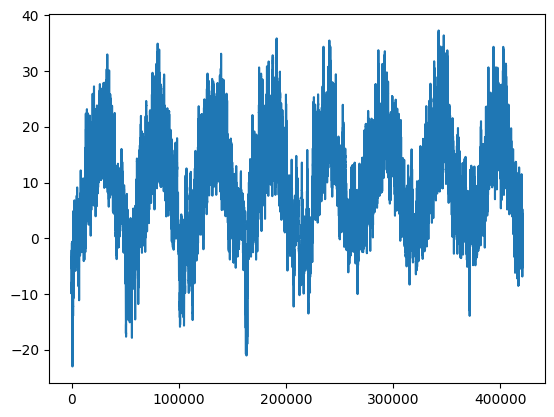

In [5]:
from matplotlib import pyplot as plt

plt.plot(range(len(temperature)), temperature)

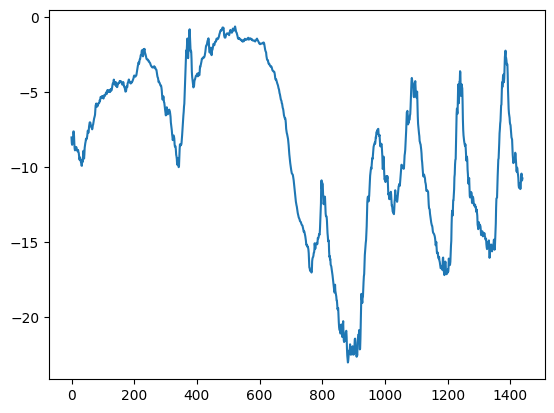

In [6]:
plt.plot(range(1440), temperature[:1440])

In [7]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


#### Preparing the data

In [8]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [9]:
import numpy as np
import keras

int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


In [10]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

In [11]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


#### A commonsense, non-machine-learning baseline

In [12]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


#### Let's try a basic machine learning model

In [13]:
import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 13.4144 - mae: 2.7916 - val_loss: 10.0418 - val_mae: 2.5054
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 8.7361 - mae: 2.3266 - val_loss: 10.3662 - val_mae: 2.5441
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 8.0129 - mae: 2.2287 - val_loss: 10.5195 - val_mae: 2.5620
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 7.5588 - mae: 2.1625 - val_loss: 11.0002 - val_mae: 2.6274
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 7.2040 - mae: 2.1096 - val_loss: 10.7027 - val_mae: 2.5866
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 6.9613 - mae: 2.0736 - val_loss: 11.1541 - val_mae: 2.6534
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 6.7158 - mae: 2.0347 - val_loss: 11.3397 - val_mae: 2.6732
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 6.6025 - mae: 2.0189 - val_loss: 11.4470 - val_mae: 2.6874
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/

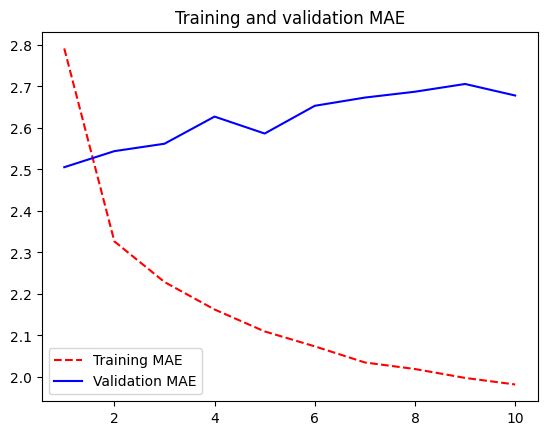

In [14]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

#### Let's try a 1D convolutional model

In [0]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

### Recurrent neural networks

In [15]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_lstm.keras")
print("Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - loss: 46.0401 - mae: 5.0178 - val_loss: 17.5495 - val_mae: 3.1207
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 14.6648 - mae: 2.9075 - val_loss: 11.4069 - val_mae: 2.5972
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 11.3620 - mae: 2.6156 - val_loss: 10.2406 - val_mae: 2.4843
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 10.6186 - mae: 2.5219 - val_loss: 9.8337 - val_mae: 2.4373
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 9.6804 - mae: 2.4140 - val_loss: 9.3300 - val_mae: 2.3850
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 9.5375 - mae: 2.3878 - val_loss: 9.1651 - val_mae: 2.3403
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 8.9521 - mae: 2.3194 - val_loss: 9.2450 - val_mae: 2.3562
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 8.6045 - mae: 2.2752 - val_loss: 9.3090 - val_mae: 2.3779
Epoch 9/10
819/819 ━━━━━━━━━━━━━━

#### Understanding recurrent neural networks

In [0]:
import numpy as np

timesteps = 100
input_features = 32
output_features = 64
inputs = np.random.random((timesteps, input_features))
state_t = np.zeros((output_features,))
W = np.random.random((output_features, input_features))
U = np.random.random((output_features, output_features))
b = np.random.random((output_features,))
successive_outputs = []
for input_t in inputs:
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
    successive_outputs.append(output_t)
    state_t = output_t
final_output_sequence = np.concatenate(successive_outputs, axis=0)

#### A recurrent layer in Keras

In [0]:
num_features = 14
inputs = keras.Input(shape=(None, num_features))
outputs = layers.SimpleRNN(16)(inputs)

In [0]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=False)(inputs)
print(outputs.shape)

In [0]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=True)(inputs)
print(outputs.shape)

In [0]:
inputs = keras.Input(shape=(steps, num_features))
x = layers.SimpleRNN(16, return_sequences=True)(inputs)
x = layers.SimpleRNN(16, return_sequences=True)(x)
outputs = layers.SimpleRNN(16)(x)

#### Getting the most out of recurrent neural networks

#### Using recurrent dropout to fight overfitting

In [0]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)

#### Stacking recurrent layers

In [16]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_stacked_gru_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - loss: 29.3707 - mae: 4.0017 - val_loss: 10.8028 - val_mae: 2.4904
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 37s 45ms/step - loss: 15.0317 - mae: 2.9977 - val_loss: 9.1856 - val_mae: 2.3303
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 37s 45ms/step - loss: 14.0198 - mae: 2.8970 - val_loss: 8.8447 - val_mae: 2.2933
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 37s 45ms/step - loss: 13.4744 - mae: 2.8399 - val_loss: 9.0218 - val_mae: 2.3263
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 37s 45ms/step - loss: 13.0534 - mae: 2.7947 - val_loss: 8.7873 - val_mae: 2.2929
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 37s 45ms/step - loss: 12.6769 - mae: 2.7570 - val_loss: 8.6621 - val_mae: 2.2752
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 37s 45ms/step - loss: 12.2680 - mae: 2.7098 - val_loss: 8.6797 - val_mae: 2.2850
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 37s 45ms/step - loss: 11.9697 - mae: 2.6791 - val_loss: 8.7059 - val_mae: 2.2902
Epoch 9/50
819/819 ━━━━━━━━━━━━

#### Using bidirectional RNNs

In [0]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
)

### Going even further